In [1]:
!python --version

Python 3.10.12


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%cd /workspace/ViCLIP-OT

/workspace/ViCLIP-OT


## Import libraries

In [126]:
from typing import Literal, Any

import matplotlib.pyplot as plt
import numpy as np
import scienceplots  # noqa: F401
import seaborn as sns
import torch
import torchvision.transforms.v2 as v2
import umap
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score
from tqdm.autonotebook import tqdm

import viclip_ot.constants as C
import viclip_ot.utils as utils
from viclip_ot.dataset import ImageTextDataset
from viclip_ot.model import ViCLIPOT, ViCLIPOTConfig
from viclip_ot.utils.logger import logger

## Config

In [227]:
SEED = 42
# DATASET_DIR = "./data/UIT-OpenViIC"
DATASET_DIR = "./data/KTVIC-dedup-against-UIT-OpenViIC"
TEST_SPLIT_NAME = "test_dedup"
MODEL_CONFIG_FILE = "./config/model.vit_base_dinov3_sbert_siglip.yaml"
# FROM_CHECKPOINT = "./checkpoints/2026-01-30_01-08-48-ablation_sbert-siglip_loss_lambda_0.1/model_epoch_29_t2i_R__1_0.4151.pth"
# FROM_CHECKPOINT = "./checkpoints/2026-01-29_22-30-24-ablation_sbert-siglip_loss_only-fixed_multiple_caps-scale_0.06-bias_-9/model_epoch_27_t2i_R__1_0.3744.pth"
FROM_CHECKPOINT = './checkpoints/siglip_sigrot.pth'
DEVICE = "auto"

## Loading model

In [228]:
utils.set_seed(SEED)
device = utils.get_device(DEVICE)
print(f"Using device: {device}")

Using device: cuda


In [229]:
model_config = ViCLIPOTConfig.model_validate(utils.load_yaml_file(MODEL_CONFIG_FILE))
print(f"Model config: {model_config}")
model = ViCLIPOT(config=model_config)
tokenizer = model.text_encoder.tokenizer
model.to(device).eval()
print(f"{model.training}")

Model config: image_config=ViCLIPOTImageConfig(model_name='timm/vit_base_patch16_dinov3.lvd1689m', pretrained=True, pool='avg', proj='linear', proj_bias=False, proj_dropout_rate=0.1) text_config=ViCLIPOTTextConfig(model_name='keepitreal/vietnamese-sbert', pretrained=True, proj='none', proj_bias=False) embed_dim=768 initial_temperature=0.06 logit_bias=-9.0
False


In [230]:
logger.info(f"Loading model from checkpoint: {FROM_CHECKPOINT}")
checkpoint = torch.load(FROM_CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"], strict=True)

2026-02-03 11:46:35.103 | INFO     | __main__:<module>:1 - Loading model from checkpoint: ./checkpoints/siglip_sigrot.pth


<All keys matched successfully>

## Loading test data

In [231]:
eval_transforms = v2.Compose(
    [
        v2.Resize(size=256, interpolation=v2.InterpolationMode.BICUBIC),
        v2.CenterCrop(size=224),
        v2.ToTensor(),
        v2.Normalize(
            mean=C.IMAGENET_DEFAULT_MEAN,
            std=C.IMAGENET_DEFAULT_STD,
        ),
    ]
)


def model_fmt() -> Literal["gemma", "e5", "qwen3", "bge", "sbert"]:
    model_name = model_config.text_config.model_name
    if "gemma" in model_name.lower():  # google/embeddinggemma-300m
        return "gemma"
    elif "e5" in model_name.lower():  # intfloat/multilingual-e5-large
        return "e5"
    elif "qwen" in model_name.lower():  # Qwen/Qwen3-Embedding-0.6B
        return "qwen3"
    elif "bge" in model_name.lower():  # BAAI/bge-m3
        return "bge"
    elif "sbert" in model_name.lower():  # keepitreal/vietnamese-sbert
        return "sbert"
    else:
        raise ValueError(f"Unsupported model name for determining model format: {model_name}")


logger.info(f"Determined model format: {model_fmt()}")

test_dataset = ImageTextDataset(
    root_dir=DATASET_DIR,
    metadata_json_file=f"{TEST_SPLIT_NAME}.json",
    image_transforms=eval_transforms,
    model_fmt=model_fmt(),
)

2026-02-03 11:46:35.905 | INFO     | __main__:<module>:30 - Determined model format: sbert
2026-02-03 11:46:35.906 | INFO     | viclip_ot.dataset:__init__:77 - Loading image text data from: ./data/KTVIC-dedup-against-UIT-OpenViIC/test_dedup.json
2026-02-03 11:46:35.910 | INFO     | viclip_ot.dataset:__init__:81 - Found 157 images and 785 annotations.


## Computing embeddings

### Image embeddings

In [232]:
all_image_features = []
all_text_features = []
batch_size = 64
with torch.no_grad():
    progress_bar = tqdm(range(0, len(test_dataset), batch_size), "Embedding images")
    for start_idx in progress_bar:
        end_idx = min(len(test_dataset), start_idx + batch_size)

        images = []
        texts = []
        for j in range(start_idx, end_idx):
            sample = test_dataset[j]
            images.append(sample[0])
            texts.append(sample[1][0])  # take the first caption only

        images = torch.stack(images).to(device)
        texts = tokenizer(
            texts, padding=True, truncation=True, max_length=1024, return_tensors="pt"
        ).to(device)

        image_features = model.encode_image(images, normalize=True)
        text_features = model.encode_text(texts, normalize=True)

        all_image_features.append(image_features.cpu())
        all_text_features.append(text_features.cpu())

    all_image_features = torch.cat(all_image_features, dim=0)
    all_text_features = torch.cat(all_text_features, dim=0)

all_image_features = all_image_features.numpy()
all_text_features = all_text_features.numpy()

print(f"{all_image_features.shape = }")
print(f"{all_text_features.shape = }")

Embedding images:   0%|          | 0/3 [00:00<?, ?it/s]

all_image_features.shape = (157, 768)
all_text_features.shape = (157, 768)


In [233]:
np.savez_compressed(f'./data/KTVIC-embeddings/{TEST_SPLIT_NAME}_siglip_sigrot.npz', image_embeddings=all_image_features, text_embeddings=all_text_features)

# np.savez_compressed(f'./data/KTVIC-embeddings/{TEST_SPLIT_NAME}_siglip.npz', image_embeddings=all_image_features, text_embeddings=all_text_features)

# np.savez_compressed(f'./data/KTVIC-embeddings/{TEST_SPLIT_NAME}_sigrot.npz', image_embeddings=all_image_features, text_embeddings=all_text_features)

# np.savez_compressed(f'./data/KTVIC-embeddings/{TEST_SPLIT_NAME}_clip.npz', image_embeddings=all_image_features, text_embeddings=all_text_features)

# np.savez_compressed(f'./data/KTVIC-embeddings/{TEST_SPLIT_NAME}_clip_sigrot.npz', image_embeddings=all_image_features, text_embeddings=all_text_features)

In [ ]:
# loaded = np.load('./data/UIT-OpenViIC-embeddings/clip_sigrot.npz')
# np.array_equal(all_image_features, loaded['image_embeddings'])
# np.array_equal(all_text_features, loaded['text_embeddings'])

True

In [14]:
def find_optimal_k(embeddings, min_k: int = 2, max_k: int = 50, sample_size: int = 5_000) -> int:
    """
    Runs K-Means for various k and plots metrics to find the best k.

    Args:
        embeddings: Your image embeddings (N, D)
        min_k, max_k: Range of k to test
        sample_size: Silhouette is slow on huge data. Sample ~5k-10k points.
    """

    # 1. Preprocessing (Normalize is crucial for Cosine Similarity proxy)
    print("Normalizing embeddings...")
    data = normalize(embeddings, axis=1, norm='l2')

    # Sampling if data is too big
    if data.shape[0] > sample_size:
        indices = np.random.choice(data.shape[0], sample_size, replace=False)
        data = data[indices]
        print(f"Sampled down to {sample_size} points for metric calculation.")

    inertias = []
    silhouettes = []
    db_scores = []
    K_range = range(min_k, max_k + 1)

    print(f"Testing k from {min_k} to {max_k}...")

    for k in K_range:
        # Run K-Means
        kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels = kmeans.fit_predict(data)

        # 1. Inertia (For Elbow Method)
        inertias.append(kmeans.inertia_)

        # 2. Silhouette Score (Higher is better)
        # This is the most important metric for cluster quality
        sil = silhouette_score(data, labels)
        silhouettes.append(sil)

        # 3. Davies-Bouldin (Lower is better)
        db = davies_bouldin_score(data, labels)
        db_scores.append(db)

        print(f"k={k}: Silhouette={sil:.4f} | DB={db:.4f}")

    # --- Plotting the Results ---
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot Inertia (Elbow)
    color = 'tab:red'
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia (Elbow)', color=color)
    ax1.plot(K_range, inertias, marker='o', color=color, linestyle='--', alpha=0.6, label='Inertia')
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot Silhouette (Right Axis)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Silhouette Score (Higher is Better)', color=color)
    ax2.plot(K_range, silhouettes, marker='s', color=color, linewidth=2, label='Silhouette')
    ax2.tick_params(axis='y', labelcolor=color)

    # Mark the Best k (Max Silhouette)
    best_k = K_range[np.argmax(silhouettes)]
    plt.axvline(x=best_k, color='green', linestyle=':', label=f'Best k={best_k}')

    plt.title("Optimal k Analysis: Elbow Method vs. Silhouette Score")
    fig.tight_layout()
    plt.show()

    return best_k

Normalizing embeddings...
Testing k from 2 to 100...
k=2: Silhouette=0.0222 | DB=5.4516
k=3: Silhouette=0.0235 | DB=5.2568
k=4: Silhouette=0.0262 | DB=5.0107
k=5: Silhouette=0.0280 | DB=5.1033
k=6: Silhouette=0.0260 | DB=4.9325
k=7: Silhouette=0.0269 | DB=4.8915
k=8: Silhouette=0.0275 | DB=4.9062
k=9: Silhouette=0.0250 | DB=4.7655
k=10: Silhouette=0.0313 | DB=4.6070
k=11: Silhouette=0.0296 | DB=4.5735
k=12: Silhouette=0.0279 | DB=4.4902
k=13: Silhouette=0.0300 | DB=4.3706
k=14: Silhouette=0.0280 | DB=4.5059
k=15: Silhouette=0.0303 | DB=4.2971
k=16: Silhouette=0.0319 | DB=4.2126
k=17: Silhouette=0.0313 | DB=4.1947
k=18: Silhouette=0.0334 | DB=4.0563
k=19: Silhouette=0.0320 | DB=4.0456
k=20: Silhouette=0.0338 | DB=3.9314
k=21: Silhouette=0.0308 | DB=3.9352
k=22: Silhouette=0.0348 | DB=3.8940
k=23: Silhouette=0.0330 | DB=3.8696
k=24: Silhouette=0.0342 | DB=3.8126
k=25: Silhouette=0.0359 | DB=3.7356
k=26: Silhouette=0.0366 | DB=3.6966
k=27: Silhouette=0.0363 | DB=3.6206
k=28: Silhouette=0.

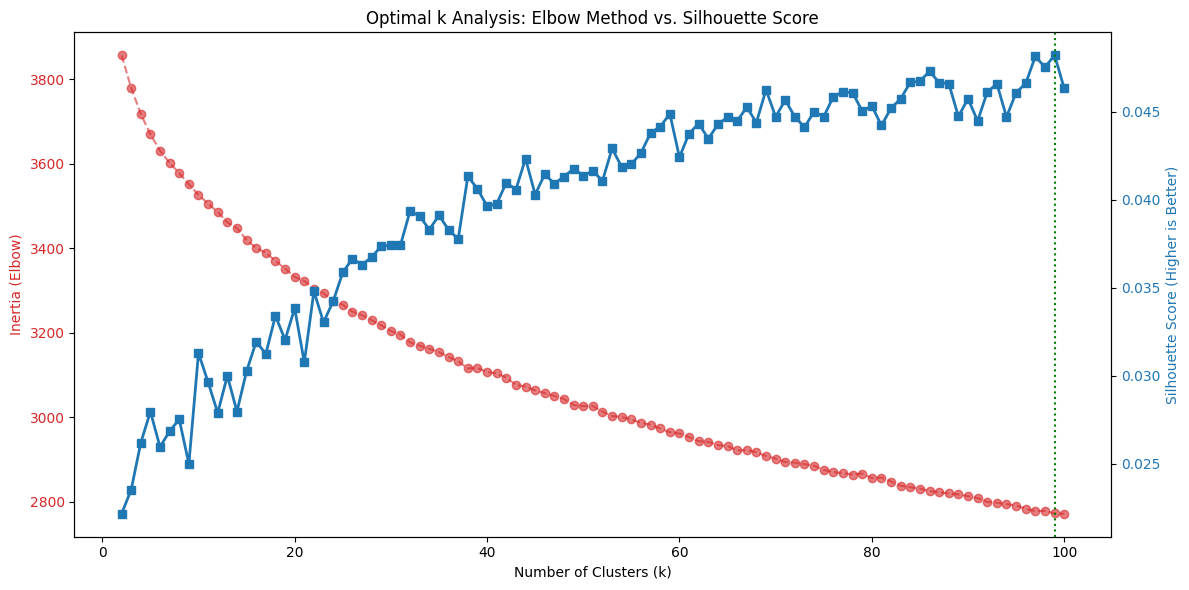

99

In [18]:
find_optimal_k(embeddings=np.vstack([all_image_features, all_text_features]), min_k=2, max_k=100, sample_size=6_000)

In [79]:
def visualize_embeddings(
    image_embeddings,
    text_embeddings=None,
    num_clusters: int = 20,
    num_samples: int = 6_000,
    title: str | None = None,
):
    """
    Args:
        image_embeddings: Numpy array (N, D)
        text_embeddings: Numpy array (N, D)
        num_clusters: How many 'concepts' to discover (K-Means)
        num_samples: Limit data size for t-SNE speed (t-SNE is slow > 5k points)
    """

    # ---------------------------------------------------------
    # 1. SAMPLING
    # t-SNE is computationally expensive. Sample N pairs randomly.
    # ---------------------------------------------------------
    total_samples = image_embeddings.shape[0]
    if total_samples > num_samples:
        indices = np.random.choice(total_samples, num_samples, replace=False)
        img_emb = image_embeddings[indices]
        txt_emb = text_embeddings[indices] if text_embeddings is not None else None
    else:
        img_emb = image_embeddings
        txt_emb = text_embeddings

    # ---------------------------------------------------------
    # 2. NORMALIZATION (Crucial Best Practice!)
    # CLIP/Dual-Encoders use Cosine Similarity. t-SNE uses Euclidean.
    # Normalizing vectors to length 1 makes Euclidean distance
    # proportional to Cosine distance.
    # ---------------------------------------------------------
    img_emb = normalize(img_emb, axis=1, norm="l2")
    if txt_emb is not None:
        txt_emb = normalize(txt_emb, axis=1, norm="l2")

    # ---------------------------------------------------------
    # 3. GENERATE PSEUDO-LABELS (The Macro View)
    # We cluster the IMAGES. We assume the Text *should* belong
    # to the same cluster as its paired image.
    # ---------------------------------------------------------
    print(f"Running K-Means (k={num_clusters}) to generate pseudo-labels...")
    kmeans = KMeans(n_clusters=num_clusters, random_state=SEED, n_init=10)
    # Fit only on images (they usually contain more robust features)
    cluster_labels = kmeans.fit_predict(img_emb)

    # ---------------------------------------------------------
    # 4. PREPARE FOR t-SNE
    # Stack images and texts together to map them into the same 2D space
    # ---------------------------------------------------------
    if txt_emb is not None:
        combined_emb = np.vstack([img_emb, txt_emb])
    else:
        combined_emb = img_emb

    # Create labels for the plot
    # 0 = Image, 1 = Text
    modality_labels = np.array(
        [0] * len(img_emb) + [1] * len(txt_emb) if txt_emb is not None else [0] * len(img_emb)
    )

    # Duplicate the cluster labels (Image i is cluster A -> Text i is also cluster A)
    combined_cluster_labels = (
        np.concatenate([cluster_labels, cluster_labels]) if txt_emb is not None else cluster_labels
    )

    # ---------------------------------------------------------
    # 5. RUN t-SNE
    # perplexity=30 is standard. learning_rate='auto' is usually best.
    # ---------------------------------------------------------
    print("Running t-SNE (this might take a moment)...")
    # tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
    tsne = umap.UMAP(
        n_neighbors=30,
        n_components=2,
        metric="euclidean",
        n_epochs=500,
        random_state=SEED,
        init="pca",
        learning_rate=1.0,
        verbose=True,
    )
    tsne_results = tsne.fit_transform(combined_emb)

    # ---------------------------------------------------------
    # 6. PLOTTING
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 10))

    # We use a distinct color palette for the clusters
    palette = sns.color_palette("tab10", num_clusters)

    # Plot Images (Circles)
    sns.scatterplot(
        x=tsne_results[modality_labels == 0, 0],  # pyright: ignore
        y=tsne_results[modality_labels == 0, 1],  # pyright: ignore
        hue=combined_cluster_labels[modality_labels == 0],
        palette=palette,
        style=None,
        marker="o",  # Circle for Image
        s=80,  # Size
        alpha=0.6,  # Transparency
        edgecolor="w",
        legend=False,  # Hide legend for now to avoid clutter
    )

    # Plot Texts (Triangles)
    sns.scatterplot(
        x=tsne_results[modality_labels == 1, 0],  # pyright: ignore
        y=tsne_results[modality_labels == 1, 1],  # pyright: ignore
        hue=combined_cluster_labels[modality_labels == 1],
        palette=palette,
        style=None,
        marker="^",  # Triangle for Text
        s=100,  # Slightly larger for text
        alpha=0.8,  # More opaque
        edgecolor="k",
        legend="full",
    )

    plt.title(
        "t-SNE of Image-Text Embeddings\n(Colors = K-Means Pseudo-Classes from Images)",
        fontsize=16,
    )
    plt.grid(True, linestyle="--", alpha=0.3)

    # Custom Legend
    from matplotlib.lines import Line2D

    custom_lines = [
        Line2D(
            [0], [0], marker="o", color="w", markerfacecolor="gray", markersize=10, label="Image"
        ),
        Line2D(
            [0], [0], marker="^", color="w", markerfacecolor="gray", markersize=10, label="Text"
        ),
    ]
    plt.legend(handles=custom_lines, loc="upper right")

    plt.tight_layout()
    plt.show()

Running K-Means (k=20) to generate pseudo-labels...
Running t-SNE (this might take a moment)...
UMAP(init='pca', n_epochs=500, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Feb  3 09:26:44 2026 Construct fuzzy simplicial set


/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Feb  3 09:26:57 2026 Finding Nearest Neighbors
Tue Feb  3 09:26:59 2026 Finished Nearest Neighbor Search
Tue Feb  3 09:26:59 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Feb  3 09:27:06 2026 Finished embedding


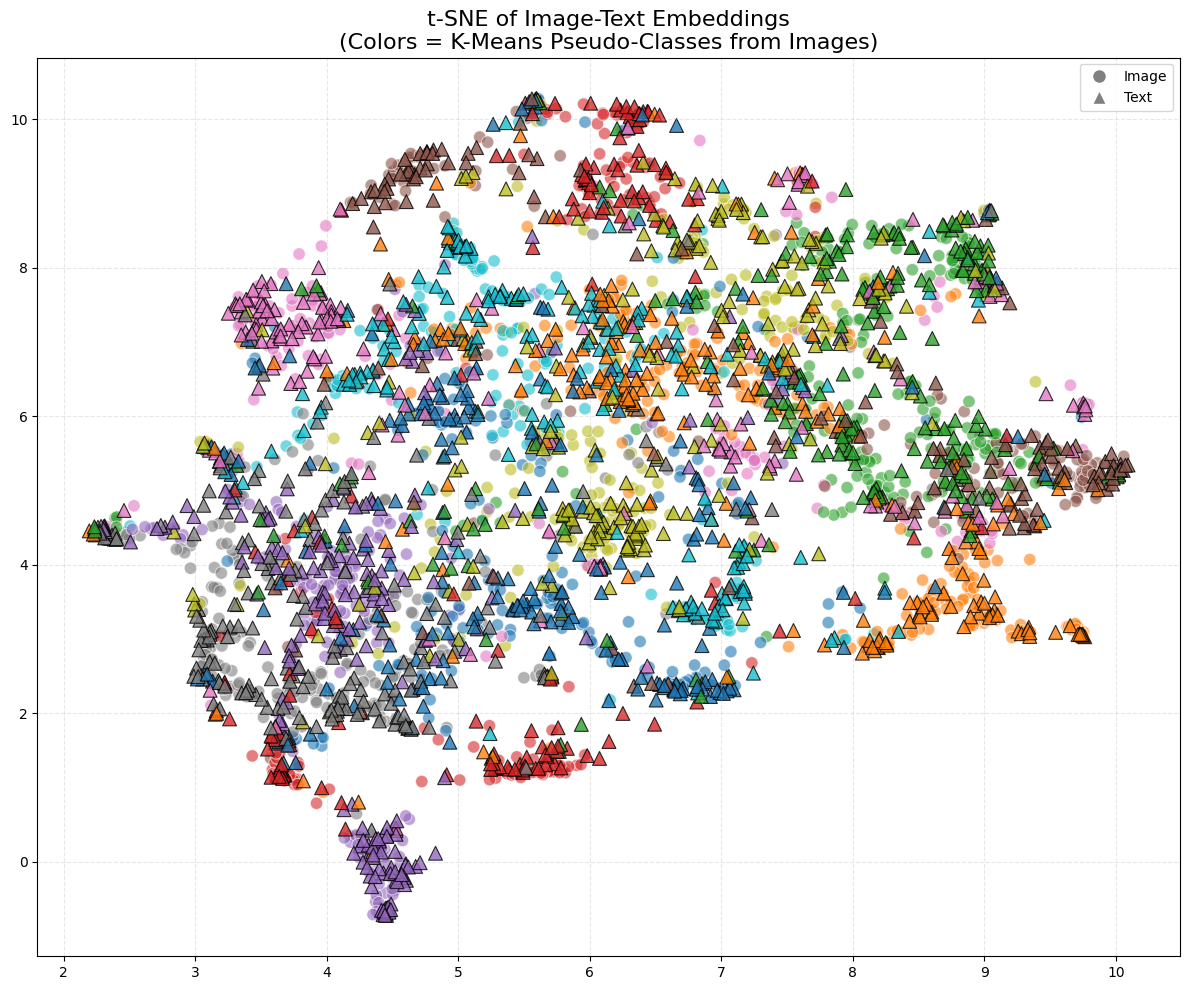

In [80]:
visualize_embeddings(
    all_image_features, all_text_features, num_clusters=20, num_samples=6_000
)

In [123]:
def visualize_embeddings(
    embeddings_list: list[dict[str, np.ndarray | str | None]],
    algorithm: Literal["tsne", "umap"] = "umap",
    num_clusters: int = 20,
    num_samples: int = 6_000,
    max_cols: int = 3,
    fig_width: float = 6.5,
    save_path: str | None = None,
):
    """
    Visualize multiple embedding sets in a grid layout.

    Args:
        embeddings_list: List of dictionaries, each containing:
            - 'image_embeddings': Numpy array (N, D)
            - 'text_embeddings': Numpy array (N, D) (optional)
            - 'title': str (optional) - title for the subplot
        num_clusters: How many 'concepts' to discover (K-Means)
        num_samples: Limit data size for UMAP speed
        max_cols: Maximum number of columns per row (default: 3)
        fig_width: Figure width in inches (default: 6.5 for elsarticle preprint)
        save_path: Path to save the figure (optional)
    """
    from matplotlib.lines import Line2D

    n_plots = len(embeddings_list)
    n_cols = min(n_plots, max_cols)
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

    # Calculate subplot size to fit within fig_width
    subplot_width = fig_width / n_cols
    subplot_height = subplot_width  # Keep subplots square
    fig_height = subplot_height * n_rows

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_width, fig_height),
        squeeze=False,
    )

    # Color palette for clusters
    palette = sns.color_palette("tab10", num_clusters)

    # Process each embedding set
    for idx, emb_dict in enumerate(embeddings_list):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]

        image_embeddings = emb_dict["image_embeddings"]
        text_embeddings = emb_dict.get("text_embeddings", None)
        title = emb_dict.get("title", f"Embedding {idx + 1}")

        # ---------------------------------------------------------
        # 1. SAMPLING
        # ---------------------------------------------------------
        total_samples = image_embeddings.shape[0]
        if total_samples > num_samples:
            indices = np.random.choice(total_samples, num_samples, replace=False)
            img_emb = image_embeddings[indices]
            txt_emb = text_embeddings[indices] if text_embeddings is not None else None
        else:
            img_emb = image_embeddings
            txt_emb = text_embeddings

        # ---------------------------------------------------------
        # 2. NORMALIZATION
        # ---------------------------------------------------------
        img_emb = normalize(img_emb, axis=1, norm="l2")
        if txt_emb is not None:
            txt_emb = normalize(txt_emb, axis=1, norm="l2")

        # ---------------------------------------------------------
        # 3. GENERATE PSEUDO-LABELS (K-Means)
        # ---------------------------------------------------------
        print(f"[{title}] Running K-Means (k={num_clusters})...")
        kmeans = KMeans(n_clusters=num_clusters, random_state=SEED, n_init=10)
        cluster_labels = kmeans.fit_predict(img_emb)

        # ---------------------------------------------------------
        # 4. PREPARE FOR UMAP or TSNE
        # ---------------------------------------------------------
        if txt_emb is not None:
            combined_emb = np.vstack([img_emb, txt_emb])
        else:
            combined_emb = img_emb

        # Create modality labels: 0 = Image, 1 = Text
        modality_labels = np.array(
            [0] * len(img_emb) + [1] * len(txt_emb) if txt_emb is not None else [0] * len(img_emb)
        )

        # Duplicate cluster labels for text
        combined_cluster_labels = (
            np.concatenate([cluster_labels, cluster_labels]) if txt_emb is not None else cluster_labels
        )

        # ---------------------------------------------------------
        # 5. RUN UMAP or TSNE
        # ---------------------------------------------------------
        print(f"[{title}] Running {algorithm.upper()}...")
        if algorithm == "umap":
            reducer = umap.UMAP(
                n_neighbors=30,
                n_components=2,
                metric="euclidean",
                n_epochs=500,
                random_state=SEED,
                init="pca",
                learning_rate=1.0,
                verbose=False,
            )
        elif algorithm == "tsne":
            reducer = TSNE(
                n_components=2,
                perplexity=30,
                max_iter=1000,
                random_state=42,
                init='pca',
                learning_rate='auto',
            )
        else:
            raise ValueError(f"Unsupported algorithm: {algorithm}")

        umap_or_tsne_results = reducer.fit_transform(combined_emb)

        # ---------------------------------------------------------
        # 6. PLOTTING on subplot
        # ---------------------------------------------------------
        # Plot Images (Circles)
        sns.scatterplot(
            x=umap_or_tsne_results[modality_labels == 0, 0],  # pyright: ignore
            y=umap_or_tsne_results[modality_labels == 0, 1],  # pyright: ignore
            hue=combined_cluster_labels[modality_labels == 0],
            palette=palette,
            marker="o",
            s=14,  # Smaller size for subplots
            alpha=0.6,
            edgecolor="w",
            linewidth=0.2,
            legend=False,
            ax=ax,
        )

        # Plot Texts (Triangles) if available
        if txt_emb is not None:
            sns.scatterplot(
                x=umap_or_tsne_results[modality_labels == 1, 0],  # pyright: ignore
                y=umap_or_tsne_results[modality_labels == 1, 1],  # pyright: ignore
                hue=combined_cluster_labels[modality_labels == 1],
                palette=palette,
                marker="^",
                s=14,
                alpha=0.6,
                edgecolor="k",
                linewidth=0.2,
                legend=False,
                ax=ax,
            )

        ax.set_title(title, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="both", which="both", labelsize=7)
        ax.grid(True, linestyle="--", alpha=0.3)

    # Hide empty subplots
    for idx in range(n_plots, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis("off")

    # Add a single shared legend
    custom_lines = [
        Line2D(
            [0], [0], marker="o", color="w", markerfacecolor="gray",
            markersize=6, label="Image", markeredgecolor="w"
        ),
        Line2D(
            [0], [0], marker="^", color="w", markerfacecolor="gray",
            markersize=6, label="Text", markeredgecolor="k"
        ),
    ]
    plt.tight_layout()

    # Adjust legend position based on figure height
    # For taller figures (fewer columns), use smaller offset
    legend_offset = 0.3 / fig_height  # Scale offset inversely with height
    top_adjust = 1 - (0.4 / fig_height)  # Scale top margin inversely with height

    fig.legend(
        handles=custom_lines,
        loc="upper center",
        bbox_to_anchor=(0.5, 1 + legend_offset),
        ncol=2,
        fontsize=8,
        frameon=False,
    )

    plt.subplots_adjust(top=top_adjust)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()


In [ ]:
def compute_alignment_score_brute_force(image_embeddings, text_embeddings) -> dict[str, Any]:
    """A brute-force implementation of alignment score and modality gap."""
    assert image_embeddings.shape == text_embeddings.shape
    N = image_embeddings.shape[0]

    text_sum = None
    image_sum = None

    sum_sim = 0
    for i in range(N):
        sim = np.dot(image_embeddings[i], text_embeddings[i])
        sum_sim += sim

        if text_sum is None:
            text_sum = text_embeddings[i].copy()
        else:
            text_sum += text_embeddings[i]

        if image_sum is None:
            image_sum = image_embeddings[i].copy()
        else:
            image_sum += image_embeddings[i]

    alignment_score = sum_sim / N

    modality_gap = np.linalg.norm((text_sum / N) - (image_sum / N))

    return {
        "alignment_score": alignment_score,
        "modality_gap": modality_gap,
    }


def compute_alignment_score(
    image_embeddings: np.ndarray, text_embeddings: np.ndarray
) -> dict[str, Any]:
    assert image_embeddings.shape == text_embeddings.shape, "Shapes must match"

    # alignment score = average cosine similarity of matched image-text pairs
    alignment_score = np.sum(image_embeddings * text_embeddings) / image_embeddings.shape[0]

    # modality gap = difference between centroids of image and text embeddings
    image_centroid = np.mean(image_embeddings, axis=0)
    text_centroid = np.mean(text_embeddings, axis=0)

    modality_gap = np.linalg.norm(text_centroid - image_centroid)

    return {
        "alignment_score": alignment_score,
        "modality_gap": modality_gap,
    }



In [241]:
embeddings_clip = np.load('./data/UIT-OpenViIC-embeddings/test_clip.npz')
embeddings_siglip = np.load('./data/UIT-OpenViIC-embeddings/test_siglip.npz')
embeddings_sigrot = np.load('./data/UIT-OpenViIC-embeddings/test_sigrot.npz')
embeddings_clip_sigrot = np.load('./data/UIT-OpenViIC-embeddings/test_clip_sigrot.npz')
embeddings_siglip_sigrot = np.load('./data/UIT-OpenViIC-embeddings/test_siglip_sigrot.npz')

In [ ]:
scores = compute_alignment_score(
    embeddings_siglip_sigrot['image_embeddings'],
    embeddings_siglip_sigrot['text_embeddings'],
)

print(f'Alignment: {scores["alignment_score"]:0.4f}')
print(f'Modality Gap: {scores["modality_gap"]:0.4f}')

Alignment: 0.3593
Modality Gap: 0.3513


In [109]:
image_embeddings = embeddings_siglip_sigrot['image_embeddings']
text_embeddings = embeddings_siglip_sigrot['text_embeddings']


In [ ]:
np.linalg.norm(image_embeddings - text_embeddings, axis=1).mean()

AttributeError: 'numpy.ndarray' object has no attribute 'pow'

[CLIP] Running K-Means (k=20)...
[CLIP] Running UMAP...


/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[SigLIP] Running K-Means (k=20)...
[SigLIP] Running UMAP...


/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[CLIP + SIGROT] Running K-Means (k=20)...
[CLIP + SIGROT] Running UMAP...


...

[SigLIP + SIGROT] Running K-Means (k=20)...
[SigLIP + SIGROT] Running UMAP...


/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[SIGROT] Running K-Means (k=20)...
[SIGROT] Running UMAP...


/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Figure saved to ./visualize_embeddings_comparison_5_models_2cols.pdf


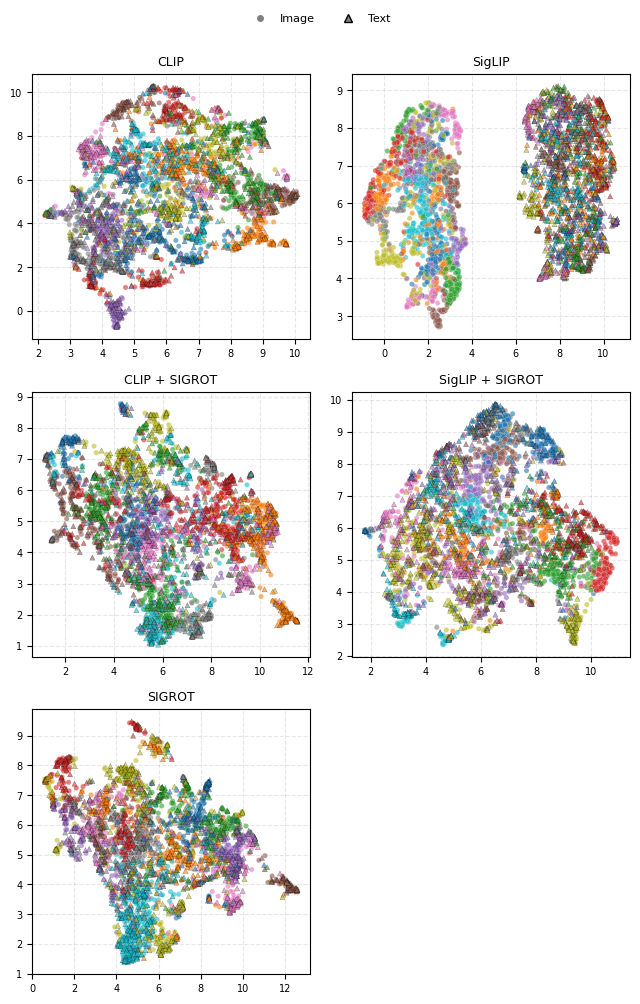

In [242]:
embeddings_list=[
    {
        "image_embeddings": embeddings_clip['image_embeddings'],
        "text_embeddings": embeddings_clip['text_embeddings'],
        "title": "CLIP",
    },
    {
        "image_embeddings": embeddings_siglip['image_embeddings'],
        "text_embeddings": embeddings_siglip['text_embeddings'],
        "title": "SigLIP",
    },
    {
        "image_embeddings": embeddings_clip_sigrot['image_embeddings'],
        "text_embeddings": embeddings_clip_sigrot['text_embeddings'],
        "title": "CLIP + SIGROT",
    },
    {
        "image_embeddings": embeddings_siglip_sigrot['image_embeddings'],
        "text_embeddings": embeddings_siglip_sigrot['text_embeddings'],
        "title": "SigLIP + SIGROT",
    },
    {
        "image_embeddings": embeddings_sigrot['image_embeddings'],
        "text_embeddings": embeddings_sigrot['text_embeddings'],
        "title": "SIGROT",
    },
]

visualize_embeddings(
    embeddings_list=embeddings_list,
    num_clusters=20,
    num_samples=6_000,
    max_cols=2,
    fig_width=6.5,  # elsarticle preprint width
    save_path="./visualize_embeddings_comparison_5_models_2cols.pdf",
)

# visualize_embeddings(
#     embeddings_list=embeddings_list,
#     num_clusters=20,
#     num_samples=6_000,
#     max_cols=1,
#     fig_width=6.5,  # elsarticle preprint width
#     save_path="./visualize_embeddings_comparison_4_models.pdf",
# )